# What builds a home fortress?

Notebook 01 established the headline number: over the matched 2012–2025 window,
Brazilian home teams collected **0.631** of all league points on offer — the
highest of six leagues, ahead of Europe's big five. That number says home
advantage is unusually large in Brazil; it doesn't say *why*.

This notebook takes it apart into three candidate explanations that are
actually testable with this dataset: the **crowd**, the **distance** a team
has to travel, and the **heat** it has to play in. Each one gets its own
natural or quasi-experiment, its own effect size, and a 95% bootstrap
confidence interval — no number below is reported without a sense of how much
to trust it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from brasileirao import analysis, features, ingest, plotting

plotting.style()
matches = ingest.load()
df = features.build_features(matches)

## 1. The crowd: what an empty stadium revealed

Between August 2020 and September 2021, Brazilian football was played behind
closed doors — no fans, in empty stadiums, as a pandemic containment measure.
Everything else about the matches stayed the same: teams flew the same
distances, played in the same stadiums, in the same climate, against the same
opposition. The only thing removed was the crowd. That makes the closed-door
window as close to a natural experiment as this dataset offers: if home
advantage falls when the crowd disappears, the drop is a reasonable estimate
of what fans themselves contribute.

We compare the closed-door window against 2017–2019 — three complete, ordinary
seasons right before the pandemic — rather than the full 2003–2024 history, so
the baseline isn't diluted by earlier or later eras of the league. The
2021 partial-attendance window (some stadiums allowed reduced crowds under
local rules) is deliberately excluded from both groups: it's neither a clean
full-crowd baseline nor a clean empty-stadium test.

Crowd effect: 0.051 points-share (95% CI 0.009..0.095), n=594 closed-door matches


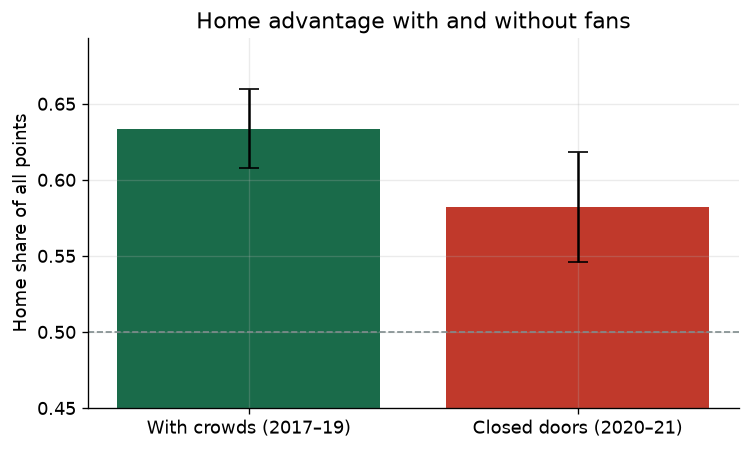

In [2]:
control = df[df.season.between(2017, 2019)]
closed = df[df.crowd == "closed"]

groups = {"With crowds (2017–19)": control, "Closed doors (2020–21)": closed}
point = {k: analysis.home_points_share(g) for k, g in groups.items()}
ci = {k: analysis.bootstrap_ci(g, analysis.home_points_share)
      for k, g in groups.items()}

diff_obs = point["With crowds (2017–19)"] - point["Closed doors (2020–21)"]
rng = np.random.default_rng(0)
diffs = []
for _ in range(2000):
    a = control.iloc[rng.integers(0, len(control), len(control))]
    b = closed.iloc[rng.integers(0, len(closed), len(closed))]
    diffs.append(analysis.home_points_share(a) - analysis.home_points_share(b))
diff_ci = (np.quantile(diffs, 0.025), np.quantile(diffs, 0.975))
print(f"Crowd effect: {diff_obs:.3f} points-share "
      f"(95% CI {diff_ci[0]:.3f}..{diff_ci[1]:.3f}), "
      f"n={len(closed)} closed-door matches")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(groups)
vals = [point[n] for n in names]
err = [[point[n] - ci[n][0] for n in names], [ci[n][1] - point[n] for n in names]]
ax.bar(names, vals, yerr=err, capsize=6,
       color=[plotting.COLORS["main"], plotting.COLORS["accent"]])
ax.axhline(0.5, color=plotting.COLORS["muted"], ls="--", lw=1)
ax.set(ylabel="Home share of all points", ylim=(0.45, None),
       title="Home advantage with and without fans")
plotting.save(fig, "crowd_effect")

### How much to trust this

This is a before/after comparison of two non-randomised windows, not a
controlled experiment, and three things temper how far to read into it:

- **Fatigue is a confounder that pushes the same direction as the crowd
  effect.** The 2020–21 season restarted five months late after the initial
  pandemic shutdown and was then played on a heavily compressed calendar,
  with many clubs juggling it alongside continental competition — the kind of
  schedule congestion known to erode home advantage on its own, independent
  of crowds. The `rest_diff` feature built above only tracks gaps between
  Brasileirão league matches, and on that narrow measure the two groups look
  similar (mean rest of 5.8 days in both) — but it can't see the cup fixtures
  that made 2020 unusually packed for many clubs, so it can't rule fatigue
  out. The crowd estimate above is best read as an upper bound on the crowd's
  own contribution.
- **The confidence interval is wide.** [0.009, 0.095] means the *direction*
  is fairly trustworthy — crowds add something — but the *size* isn't: the
  true effect could be as small as 1 point per 100, or as large as nearly 10.
- **A single season would not have shown this cleanly, and that's worth
  saying plainly.** 2017 — a full, ordinary, full-crowd season — had a
  *lower* home points share (0.582) than the closed-door season of 2020
  (0.602). Read season by season, the closed-door year does not look like the
  outlier; year-to-year noise across a 380-match season is larger than the
  crowd effect itself. That is exactly why this analysis compares the
  closed-door *window* against a three-season *baseline*, match by match,
  instead of eyeballing one number per season — the bar chart above is doing
  real statistical work, not restating something visible to the naked eye.

## 2. The 3,000 km away day

Brazil is a continental-scale country: the average away trip in this dataset
covers 946 km, some fixtures top 3,200 km — roughly London to Moscow — and
5.6% of matches are same-city derbies with no travel at all. If travel tires
teams out or disrupts their routine, it should show up as worse away results
the farther the away team has flown.

The obvious trap: teams that travel the farthest aren't a random sample of
opponents. A smaller club from a distant state might travel far only to face
bigger, richer opposition, so distance and away-team weakness would be tangled
together if every fixture were compared as-is. We use a balance trick to cut
that out: restrict to fixtures where the two teams are evenly matched on paper
before kickoff (`|elo_diff| <= 75`), so distance isn't standing in for "weak
team visits strong team." That narrows the dataset from 8,785 to 5,626
matches. The mean Elo difference within each travel bin, reported alongside
the results below, is the evidence the balancing actually worked — it should
sit close to zero in every bin.

         bin  away_share        lo        hi     n  mean_elo_diff
0    <400 km    0.354779  0.334417  0.376391  1792      -0.604719
1   400–1200    0.358417  0.339979  0.376121  2251      -1.484922
2  1200–2200    0.377953  0.351759  0.404789  1118      -1.392843
3   >2200 km    0.306604  0.269951  0.345401   465      -3.018411


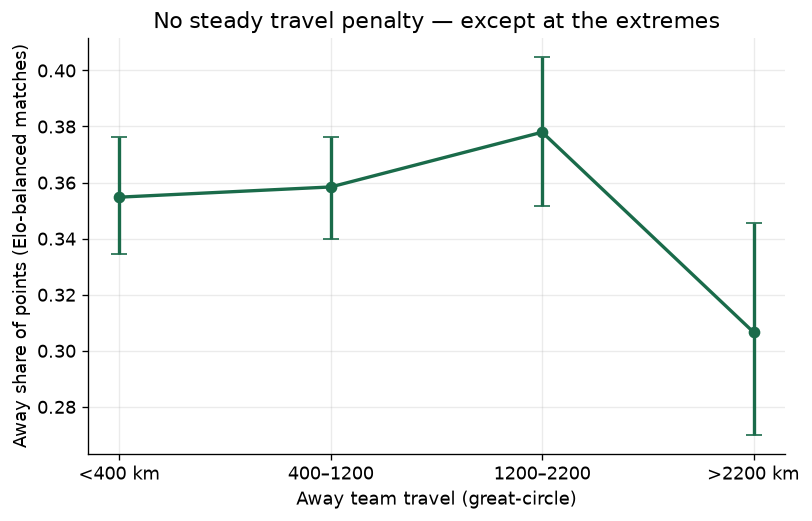

In [3]:
BINS = [0, 400, 1200, 2200, 4000]
LABELS = ["<400 km", "400–1200", "1200–2200", ">2200 km"]

even = df[df.elo_diff.abs() <= 75].copy()
# pd.cut is left-exclusive by default, which would silently drop the 333
# zero-distance same-city derbies in this Elo-balanced subset from every
# bin. They belong in the shortest-distance bucket, so include_lowest=True
# keeps them instead of turning them into NaNs.
even["bin"] = pd.cut(even.travel_km, BINS, labels=LABELS, include_lowest=True)

rows = []
for b, g in even.groupby("bin", observed=True):
    lo, hi = analysis.bootstrap_ci(g, analysis.away_points_share)
    rows.append({"bin": b, "away_share": analysis.away_points_share(g),
                 "lo": lo, "hi": hi, "n": len(g),
                 "mean_elo_diff": g.elo_diff.mean()})
travel = pd.DataFrame(rows)
print(travel)  # mean_elo_diff per bin ~0 shows the control is working

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = range(len(travel))
ax.errorbar(x, travel.away_share,
            yerr=[travel.away_share - travel.lo, travel.hi - travel.away_share],
            fmt="o-", color=plotting.COLORS["main"], capsize=5, lw=2)
ax.set_xticks(list(x), travel.bin)
ax.set(xlabel="Away team travel (great-circle)",
       ylabel="Away share of points (Elo-balanced matches)",
       title="No steady travel penalty — except at the extremes")
plotting.save(fig, "travel_effect")

## 3. Playing in another climate

Brazil spans everything from temperate Porto Alegre in the south to the
tropical, often 30°C+ heat of the Northeast. A southern club that has to visit
Fortaleza or Salvador is playing in a genuinely different climate from the one
it trains in every week — a plausible extra burden layered on top of travel.
We reuse the same Elo-balanced subset and the same logic as the travel test:
bin fixtures by how much hotter or colder the match city is than the away
team's home city, and compare away performance across bins.

                bin  away_share        lo        hi     n
0  Colder than home    0.339535  0.319624  0.360099  1649
1           Similar    0.363636  0.347133  0.379797  2796
2  Hotter than home    0.365079  0.339117  0.389205  1181


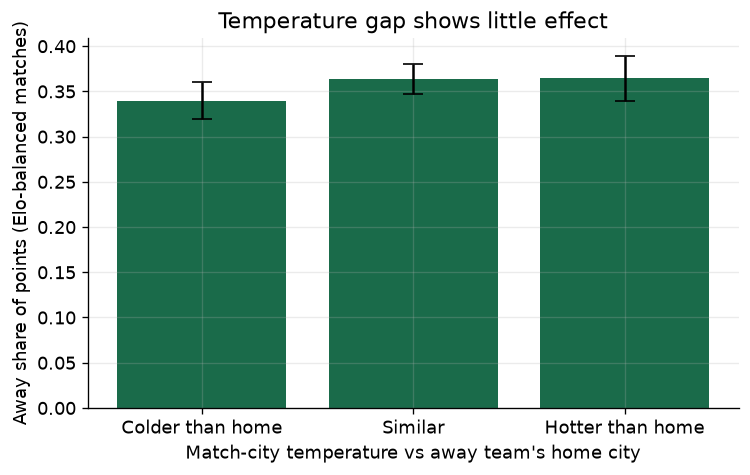

In [4]:
even["heat_bin"] = pd.cut(even.temp_gap, [-15, -3, 3, 15],
                          labels=["Colder than home", "Similar", "Hotter than home"])
rows = []
for b, g in even.groupby("heat_bin", observed=True):
    lo, hi = analysis.bootstrap_ci(g, analysis.away_points_share)
    rows.append({"bin": b, "away_share": analysis.away_points_share(g),
                 "lo": lo, "hi": hi, "n": len(g)})
heat = pd.DataFrame(rows)
print(heat)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(heat.bin.astype(str), heat.away_share,
              yerr=[heat.away_share - heat.lo, heat.hi - heat.away_share],
              capsize=6, color=plotting.COLORS["main"])
ax.set(ylabel="Away share of points (Elo-balanced matches)",
       xlabel="Match-city temperature vs away team's home city",
       title="Temperature gap shows little effect")
plotting.save(fig, "heat_effect")

In [5]:
rest_bins = pd.cut(even.rest_diff, [-15, -2, 2, 15],
                   labels=["Home more tired", "Similar", "Home fresher"])
print(even.groupby(rest_bins, observed=True).apply(
    analysis.home_points_share, include_groups=False).round(3))

rest_diff
Home more tired    0.626
Similar            0.645
Home fresher       0.621
dtype: float64


Rest doesn't show a clean pattern either: home teams that are relatively
*more* rested than their opponents post a home share of 0.621, barely
different from — and, if anything, slightly below — the 0.645 seen when both
sides are similarly rested, with the "home more tired" bin (0.626) sitting in
between. The two extreme bins hold only 180 and 253 matches, so this is well
within noise. And despite the intuition that a longer trip should mean less
recovery time, `travel_km` and `rest_diff` turn out to be barely correlated in
this data (r ≈ 0.03) — `rest_diff` here only tracks gaps between Brasileirão
league matches, so it misses recovery time lost to cup and continental
fixtures. More generally, Elo, travel, heat, rest and crowd status all vary
together across matches in ways a simple bin-by-bin split can't fully pull
apart; that joint disentangling is the job of the regression model in
notebook `03_model_and_shap.ipynb`.

## What we found

Three effects, three different levels of confidence:

- **Crowd: +0.051 points-share (95% CI 0.009–0.095).** Removing fans from the
  stadium closed just over 5 percentage points of the gap between home and
  away teams — real (the interval excludes zero), but wide enough that the
  true size could be anywhere from barely-there to substantial. A congested
  2020–21 calendar likely inflates this estimate somewhat, since fatigue and
  crowd absence can't be fully separated with this data.
- **Travel: no steady penalty across most of the range, but a real drop at
  the very longest trips.** Away performance actually *rose* slightly, not
  fell, as travel went from under 400 km to 1,200–2,200 km — the opposite of
  the "farther is harder" story, and each of those bins' intervals overlaps
  its neighbours. Only the longest trips (>2,200 km, 465 matches) broke from
  that pattern, landing about 7 points lower than the 1,200–2,200 km bin
  (95% CI 0.025–0.116 on that specific comparison) — worth a closer look in
  notebook 03's regression, but not evidence of a smooth, monotonic travel
  penalty.
- **Heat: no detectable effect.** Away teams walking into conditions hotter
  than what they're used to (0.365) performed statistically
  indistinguishably from those in similar conditions (0.364) or colder ones
  (0.340) — every interval overlaps the others. Whatever gives Brazilian home
  teams their edge, this climate-gap measure doesn't capture it.

Crowd support is the one factor this notebook can defend with a number.
Travel and heat, tested one at a time on a simple bin split, are not doing
the heavy lifting the pre-registered hypotheses expected — a genuinely useful
null result, since it narrows down what's left to explain. Notebook
`03_model_and_shap.ipynb` puts all of these features — Elo, travel, heat,
rest, crowd — into a single model, so they compete for the same variance
instead of being tested one at a time, and checks with SHAP whether travel's
extreme-distance effect survives once everything else is controlled for.